NOTE: EDA FOR THE 10 SELECTED FEATURES THAT WE USE AS INPUTS IN OUR MODEL IS IN THE test_benchmar.ipynb file

# Modules and classes

In [1]:
# Numerical & data handling
import numpy as np
import pandas as pd
import math

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import LabelEncoder, PowerTransformer, StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Specialized packages
from ISLP import confusion_table

# Functions

In [2]:
def plot_histograms(df, response=None, bins=30, grid_shape=(8,6)):
   
    fig, axes = plt.subplots(*grid_shape, figsize=(20,20))
    axes = axes.flatten()
    
    for i, col in enumerate(df.columns):
        if response is None:
            sns.histplot(df[col], bins=bins, ax=axes[i], kde=False)
        else:
            sns.histplot(data=df, x=col, hue=response, bins=bins, ax=axes[i],
                         element="step", stat="density", common_norm=False)
        axes[i].set_title(col)
    
    plt.tight_layout()
    plt.show()

In [3]:
def plot_boxplots(df, by=None, ncols=6, figsize=(18,6)):
    """
    Automatically detect all numeric columns in df and plot boxplots.
    Arranges them in a grid with ncols per row.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    by : str, optional
        Column to group by (categorical variable).
    ncols : int, default=6
        Number of plots per row.
    figsize : tuple, default=(18,6)
        Size of each row of plots.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing all boxplots.
    """
    sns.set_theme(style="whitegrid")
    
    # detect numeric columns automatically
    columns = df.select_dtypes(include="number").columns
    n = len(columns)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1]*nrows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]
        if by:
            sns.boxplot(x=by, y=col, data=df, ax=ax)
        else:
            sns.boxplot(y=df[col], ax=ax)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel(by if by else "")
        ax.set_ylabel(col)

    # hide unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    sns.despine()
    plt.tight_layout()
    plt.show()
    return None

In [4]:
def plot_pairplot(df, hue=None):

    if hue is not None:
        df_plot = df.copy()
        df_plot['__hue__'] = hue  # temporary column
        return sns.pairplot(df_plot, hue='__hue__')
    else:
        return sns.pairplot(df)

In [5]:
def plot_heatmap(df, title = None, method='pearson', cmap='coolwarm', annot=False, figsize=(12,10)):
    corr = df.corr(method=method)
    plt.figure(figsize=figsize)
    sns.heatmap(corr, cmap=cmap, annot=annot, fmt=".2f", center=0,
                square=True, linewidths=0.5, linecolor='white',
                cbar_kws={"shrink": 0.8})
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    if title is None:
        plt.title(f"{method.capitalize()} Correlation Heatmap", fontsize=14)
    else:
        plt.title(title, fontsize=14)
    
    plt.tight_layout()
    plt.show()

In [6]:
def preprocess_split(X, y, train_years=(2014,2022), test_years=(2023,2024)):
    
    # Extract years from index
    years = pd.Series(X.index.astype(str).str[-4:].astype(int), index=X_df.index)
    train_mask = years.between(*train_years)
    test_mask  = years.between(*test_years)
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    
    # Build preprocessing pipeline: impute → transform → scale
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('yeojohnson', PowerTransformer(method='yeo-johnson')),
        ('scaler', StandardScaler())
    ])
    
    # Fit-transform training, transform test
    X_tr_sc = pipeline.fit_transform(X_train)
    X_ts_sc = pipeline.transform(X_test)
    
    X_tr_sc = pd.DataFrame(X_tr_sc, columns=X_train.columns, index=X_train.index)
    X_ts_sc = pd.DataFrame(X_ts_sc, columns=X_test.columns, index=X_test.index)
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)
    y_test_enc  = label_encoder.transform(y_test)
    
    return X_train, X_test, y_train_enc, y_test_enc, X_tr_sc, X_ts_sc, pipeline, label_encoder

In [7]:
def evaluate_kmeans(X_train, k_range=range(2,10)):
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    import matplotlib.pyplot as plt
    
    wcss, sil_scores = [], []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42).fit(X_train)
        wcss.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(X_train, kmeans.labels_))
    
    plt.plot(k_range, wcss, 'bx-'); plt.title("Elbow Method"); plt.show()
    plt.plot(k_range, sil_scores, 'ro-'); plt.title("Silhouette Method"); plt.show()


In [8]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    from sklearn.metrics import classification_report, confusion_matrix
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    return model, y_pred


In [9]:
def describe_categorical(series, plot=True):
   
    # Frequency and proportion
    counts = series.value_counts()
    proportions = series.value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': counts,
        'Percentage': proportions.round(2)
    }).sort_values('Count', ascending=False)

    # Visualization
    if plot:
        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=summary.index, y=summary['Count'], palette='Set2')

        # Add value labels
        for i, count in enumerate(summary['Count']):
            ax.text(i, count + max(summary['Count']) * 0.01, f'{count}', ha='center', va='bottom', fontsize=10)

        plt.title("Category Distribution of tcri", fontsize=14)
        plt.xlabel("TCRI Category")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha='right')
        sns.despine()
        plt.tight_layout()
        plt.show()
    
    return summary


In [10]:
import pandas as pd

def split_describe_with_distribution(df, chunk_size=6):
    """
    Generate descriptive statistics in chunks for readability,
    including skewness and kurtosis.
    Each chunk shows up to `chunk_size` columns, stacked vertically.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe with numeric predictors.
    chunk_size : int, default=6
        Number of columns per table.

    Returns
    -------
    tables : list of pandas.DataFrame
        List of describe() tables, each with skewness and kurtosis.
    """
    tables = []
    cols = df.select_dtypes(include="number").columns

    for i in range(0, len(cols), chunk_size):
        subset = df[cols[i:i+chunk_size]]
        desc = subset.describe()

        # Add skewness and kurtosis
        skewness = subset.skew(numeric_only=True)
        kurtosis = subset.kurtosis(numeric_only=True)

        extra = pd.DataFrame({
            "skewness": skewness,
            "kurtosis": kurtosis
        })

        # Concatenate describe stats with skew/kurtosis
        combined = pd.concat([desc.T, extra], axis=1)

        tables.append(combined)

    return tables


In [11]:
def summarize_outliers_zscore(df, threshold=3.0):
    
    import pandas as pd
    import numpy as np

    df_numeric = df.select_dtypes(include=[np.number])
    zscores = (df_numeric - df_numeric.mean()) / df_numeric.std(ddof=0)
    outlier_mask = (zscores.abs() > threshold)

    outlier_counts = outlier_mask.sum()
    total_counts = df_numeric.shape[0]
    outlier_percentages = (outlier_counts / total_counts * 100).round(2)

    summary = pd.DataFrame({
        'Outlier Count': outlier_counts,
        'Outlier Percentage': outlier_percentages
    }).sort_values('Outlier Count', ascending=False)

    return summary


In [12]:
def summarize_in_blocks(df, block_size=5, round_digits=2):
    """
    Prints descriptive statistics with skewness and kurtosis in blocks of N predictors.

    Parameters:
        df (pd.DataFrame): Input DataFrame with numeric columns.
        block_size (int): Number of predictors per block.
        round_digits (int): Decimal places to round statistics.
    """
    # Compute describe + skewness + kurtosis
    desc = df.describe().T.copy()
    desc['skewness'] = df.skew()
    desc['kurtosis'] = df.kurtosis()
    desc = desc.round(round_digits)

    # Split into blocks
    rows = desc.index.tolist()
    blocks = [rows[i:i+block_size] for i in range(0, len(rows), block_size)]

    for i, block in enumerate(blocks):
        print(f"\n▶️ Block {i+1} (Predictors {block[0]} to {block[-1]}):")
        display(desc.loc[block])


# Data preprocessing

In [13]:
# Import dataset
tej = pd.read_csv("tej.csv", index_col = 0)

# Replace '-' with NaN
tej.replace('-', np.nan, inplace=True)

Calculating missing values in the dataset and present it in a table.

In [14]:
# Count missing values
missing_counts = tej.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

# Calculate percentage with 4 significant figures
missing_percent = (missing_counts / len(tej)) * 100
missing_percent = missing_percent.apply(lambda x: float(f"{x:.4g}"))

# Combine and sort by count
missing_table = pd.DataFrame({
    'Variable': missing_counts.index,
    'Missing Values': missing_counts.values,
    'Missing (%)': missing_percent.values
}).sort_values(by='Missing Values', ascending=False)

missing_table

,Variable,Missing Values,Missing (%)
1,expected credit impairment (loss) profit - ope...,2437,36.79000
10,retention ratio,1455,21.97000
3,operating leverage,956,14.43000
2,financial leverage,845,12.76000
0,r&d expense,232,3.50200
4,interest coverage ratio,191,2.88300
7,cash flow adequacy ratio,107,1.61500
8,cash reinvestment ratio,36,0.54350
9,contingent liabilities to net worth,2,0.03019
6,roe - comprehensive income,1,0.01510


Splitting the dataset into predictors and response variable.

In [15]:
# Splitting dataset into predictors and response variable
X_tej = tej.iloc[:, :-1]
y_tej = tej.iloc[:, -1]

In the dataset, there are only 2 observations in the TCRI column with rating C, so we exclude that because it ruins our model.

In [16]:
# Convert y to a pandas Series if it's not already
y_series = pd.Series(y_tej)

# Identify rows where y != 5
mask = y_series != 'C'

# Filter both X and y
X_filtered = X_tej[mask]
y_filtered = y_series[mask]

Imputing missing values in the predictors.

In [17]:
# Imputing missing values
imputer = SimpleImputer(missing_values = np.nan, strategy = 'median')
imputer.fit(X_filtered)
X = imputer.transform(X_filtered)
X_df = pd.DataFrame(X, columns= X_filtered.columns, index = X_filtered.index)

Labeling the response variable into factors.

In [18]:
# LabelEncoding the multiclass response variable
le = LabelEncoder()
y = le.fit_transform(y_filtered)

Descriptive statistics for all predictors.

In [19]:
summarize_in_blocks(X_df, block_size= 48)


▶️ Block 1 (Predictors cash and cash equivalents to dividend payout ratio):


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
cash and cash equivalents,6622.0,2031160.22,6681963.97,1.125000e+03,319784.25,701200.50,1517499.50,1.494280e+08,10.50,145.28
current assets,6622.0,8678525.12,29277931.84,1.526000e+04,1446458.50,2779874.00,6564517.25,6.832920e+08,13.36,235.91
total assets,6622.0,18776722.90,71559079.54,1.726700e+04,2764087.75,5434440.50,12432489.75,1.657802e+09,12.45,204.25
current liabilities,6622.0,5896663.70,28378831.46,7.760000e+02,653886.00,1491492.00,3771463.25,7.934215e+08,18.69,421.01
total liabilities,6622.0,11552982.53,62382019.86,4.946000e+03,944673.75,2295347.00,5886414.00,1.607622e+09,15.82,307.62
common shares,6622.0,3387926.46,7639833.08,1.427190e+05,871349.50,1489517.50,3005155.50,1.055962e+08,7.77,77.31
share capital,6622.0,3400313.46,7710776.71,1.576000e+05,875460.00,1490550.00,3005579.00,1.055962e+08,7.85,78.69
total capital,6622.0,1191068.29,5305519.35,-2.070880e+05,59116.25,305537.50,879875.25,1.059197e+08,14.13,236.68
retained earnings,6622.0,2141344.90,7689971.45,-4.665874e+07,187388.25,724805.00,1799004.25,2.800772e+08,15.65,413.02
total shareholder's equity,6622.0,7223740.37,18046458.62,2.927000e+03,1610381.25,2993183.50,6311369.00,3.437860e+08,9.12,109.64


In [27]:
y_series = pd.Series(y_tej)

# count each class
counts = y_series.value_counts()

# percentage of each class
percentages = y_series.value_counts(normalize=True) * 100

# combine into one table
summary = pd.DataFrame({
    'Class': counts.index,
    'Count': counts.values,
    'Percentage (%)': percentages.values.round(2)
})

print(summary)

  Class  Count  Percentage (%)
0     6   2161           32.62
1     5   2054           31.01
2     7   1389           20.97
3     8    667           10.07
4     9    292            4.41
5     D     59            0.89
6     C      2            0.03


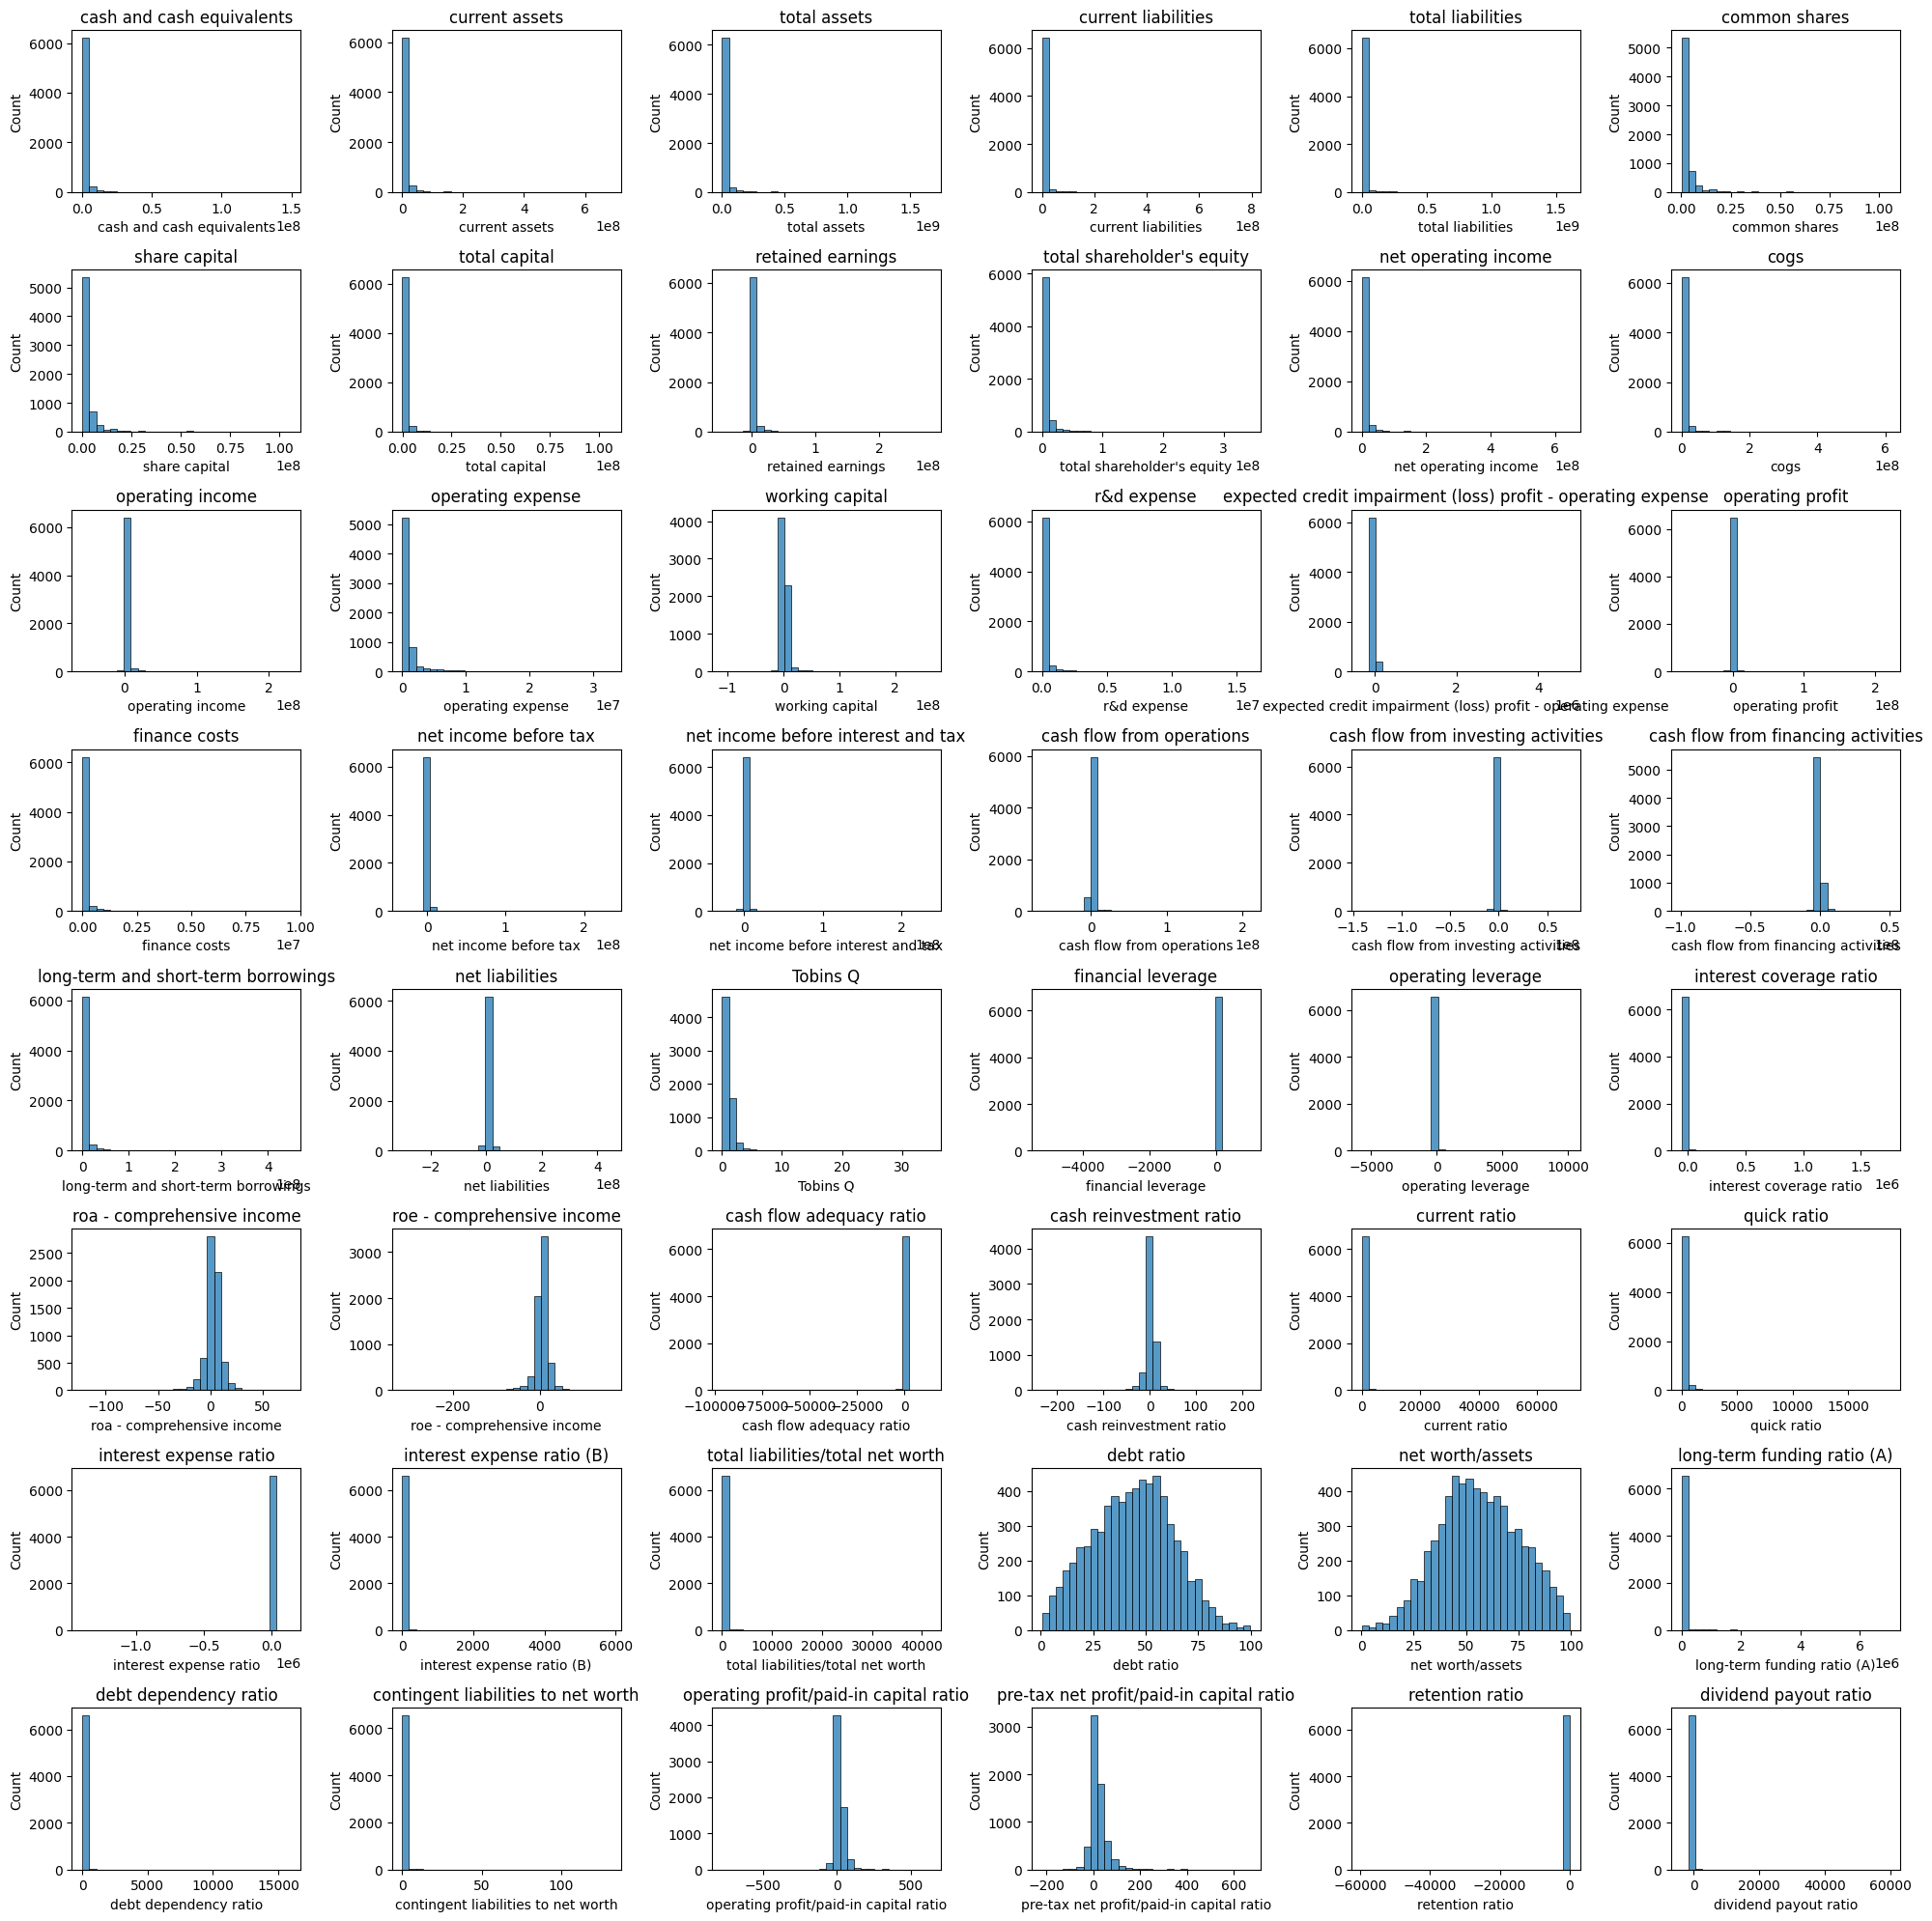

In [20]:
plot_histograms(X_df)

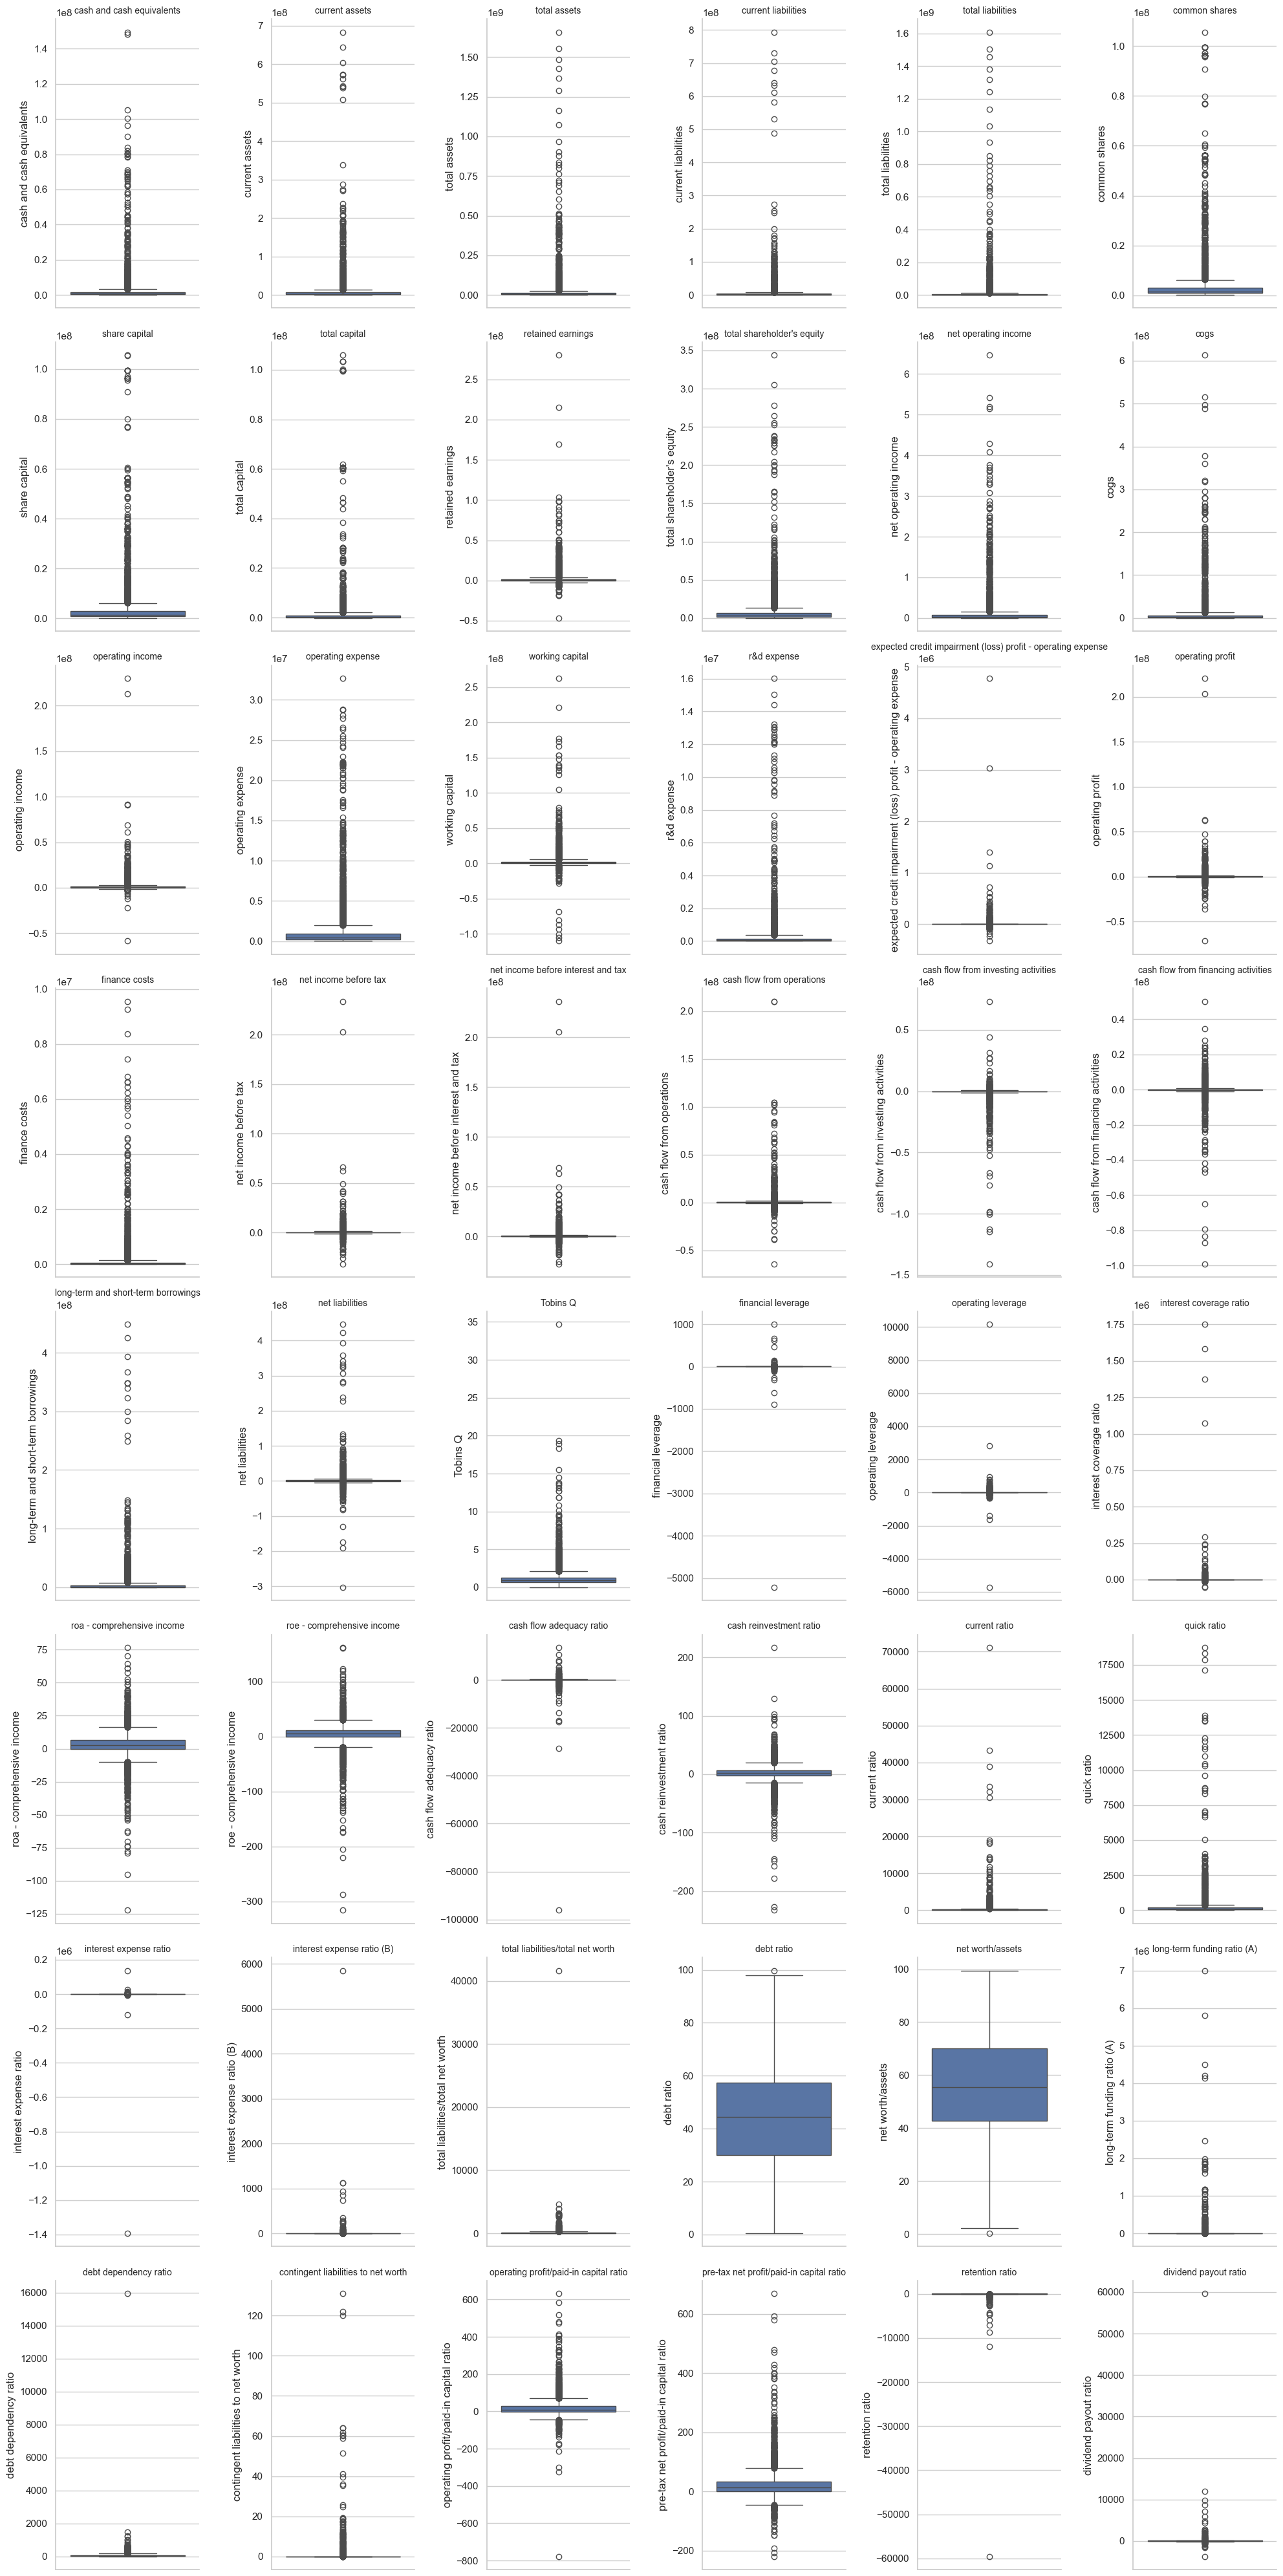

In [21]:
plot_boxplots(X_df, figsize= (20, 5))

In [22]:
summarize_outliers_zscore(X_df)

,Outlier Count,Outlier Percentage
operating expense,130,1.96
roa - comprehensive income,117,1.77
common shares,114,1.72
share capital,114,1.72
roe - comprehensive income,111,1.68
cash reinvestment ratio,109,1.65
net operating income,108,1.63
cogs,107,1.62
pre-tax net profit/paid-in capital ratio,103,1.56
Tobins Q,96,1.45
